<a href="https://colab.research.google.com/github/Keshav-Agrawal654/Keshav_23FE10CSE00810_MLlab/blob/main/lab7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset shape: (862, 30)
Missing values per column:
Age    5
dtype: int64

Total missing values: 5
Dataset shape after dropping missing values: (857, 30)
Target distribution:
target
0    497
1    360
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 857 entries, 0 to 861
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Grade              857 non-null    object 
 1   Project            857 non-null    object 
 2   Case_ID            857 non-null    object 
 3   Gender             857 non-null    object 
 4   Age_at_diagnosis   857 non-null    object 
 5   Primary_Diagnosis  857 non-null    object 
 6   Race               857 non-null    object 
 7   IDH1               857 non-null    int64  
 8   TP53               857 non-null    int64  
 9   ATRX               857 non-null    int64  
 10  PTEN               857 non-null    int64  
 11  EGFR               857 non-null    int64  
 1

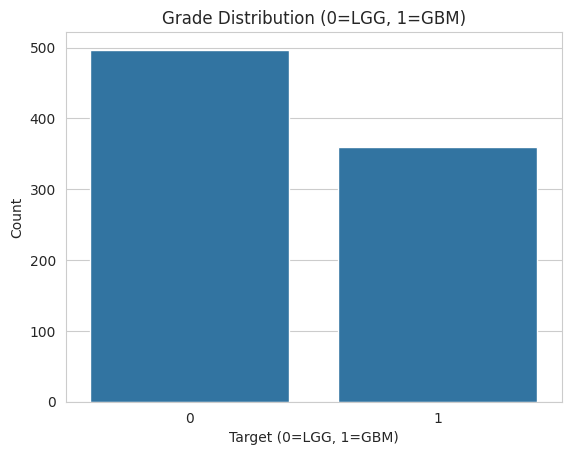

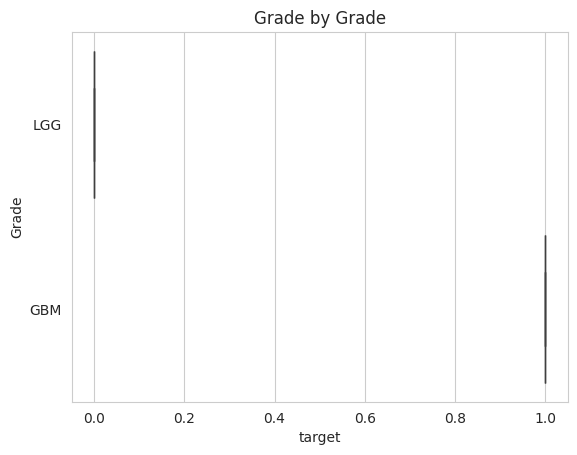

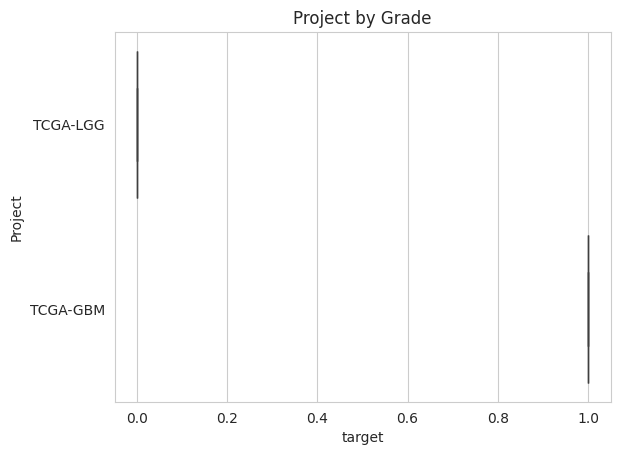

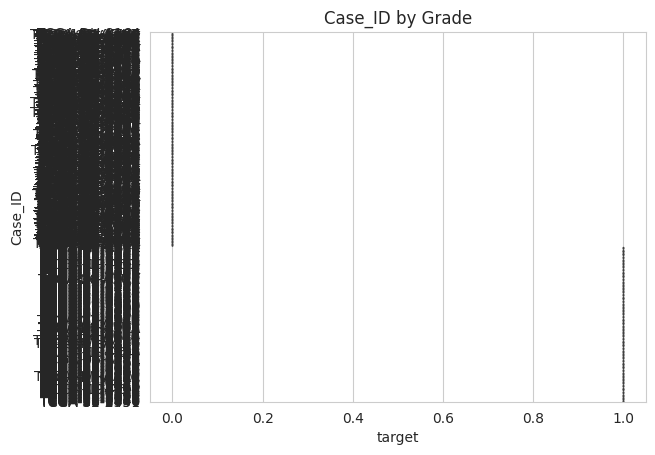

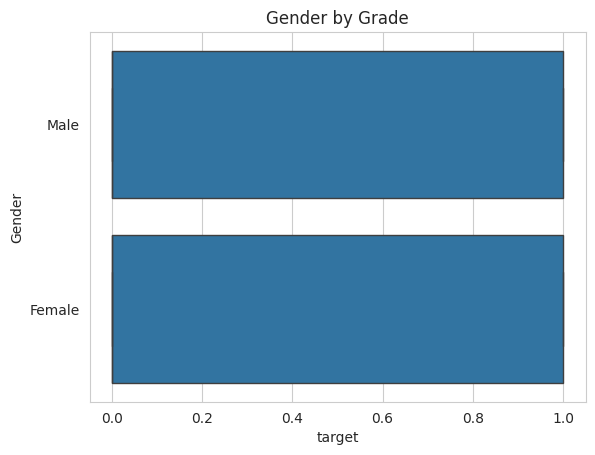

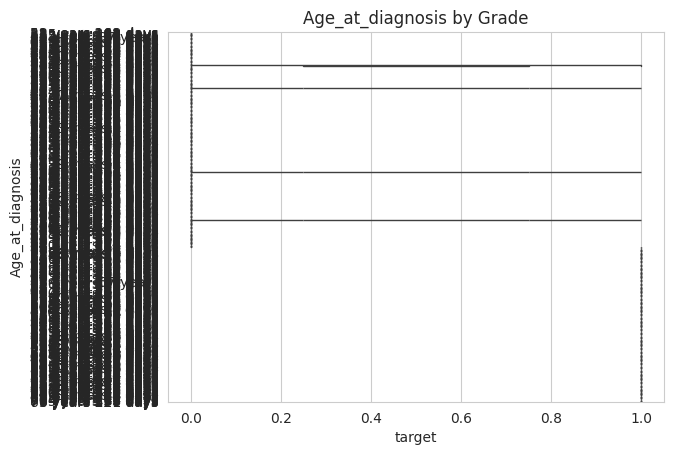

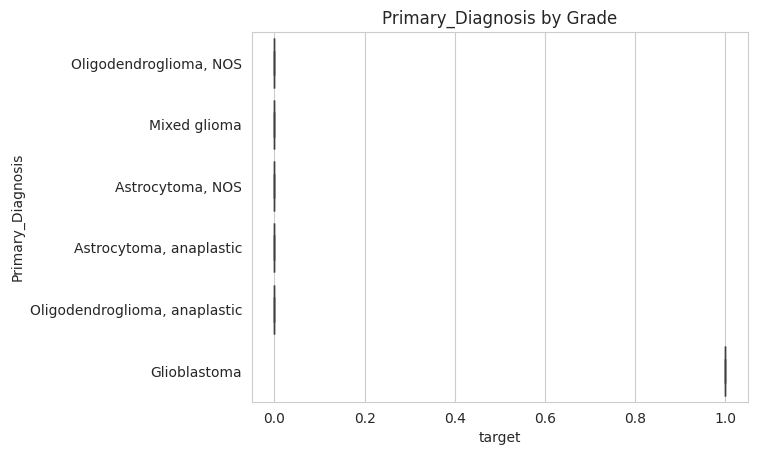

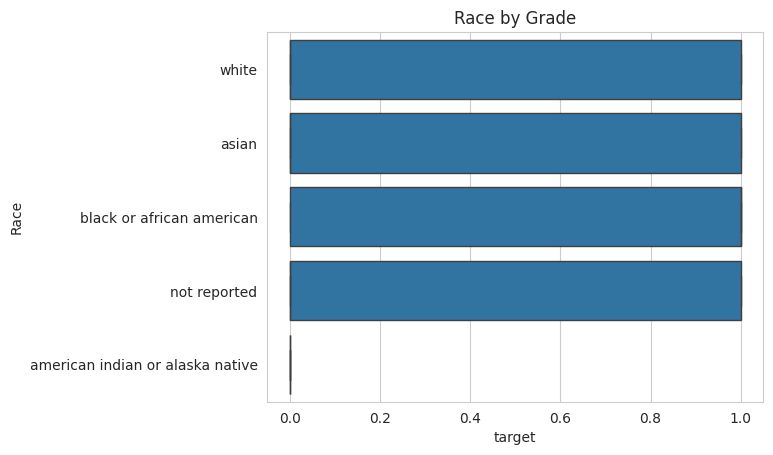

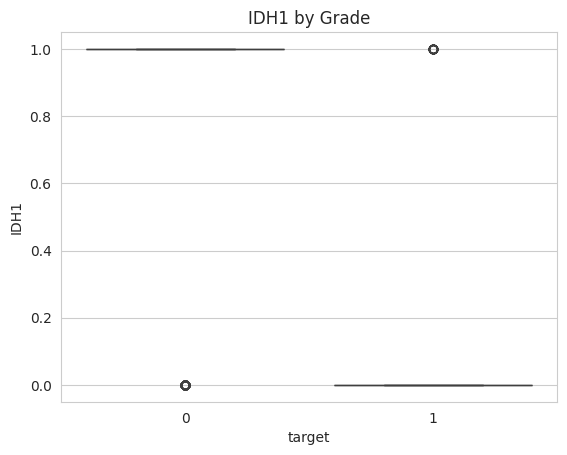

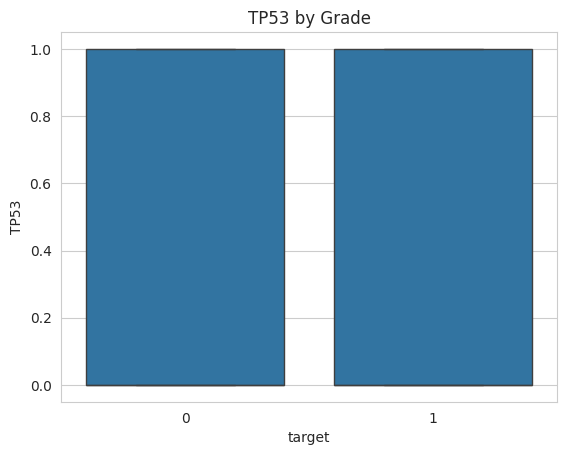

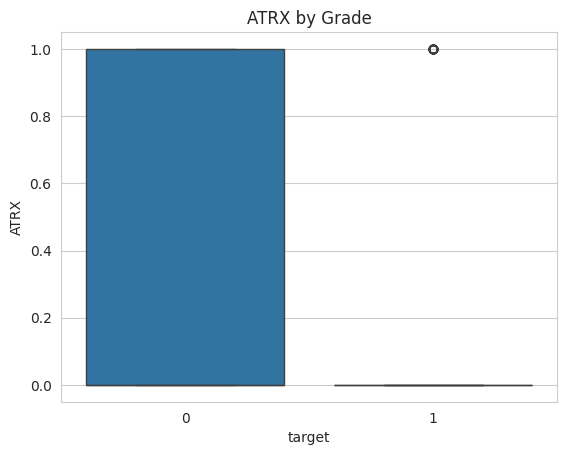

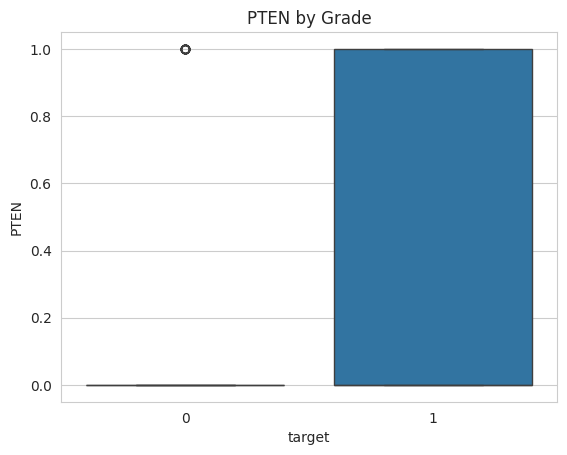

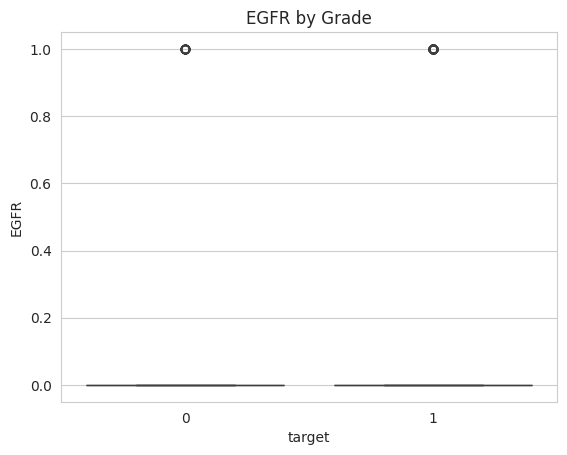

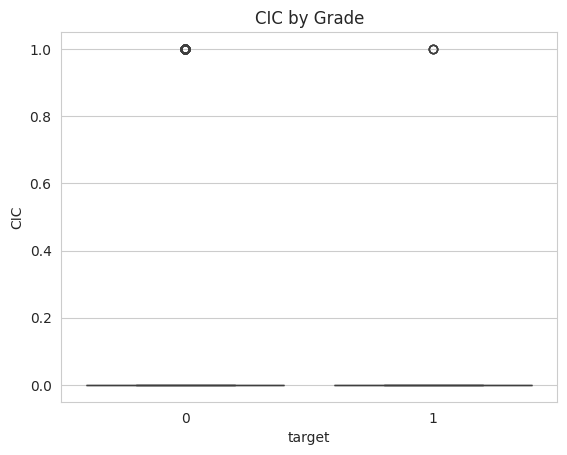

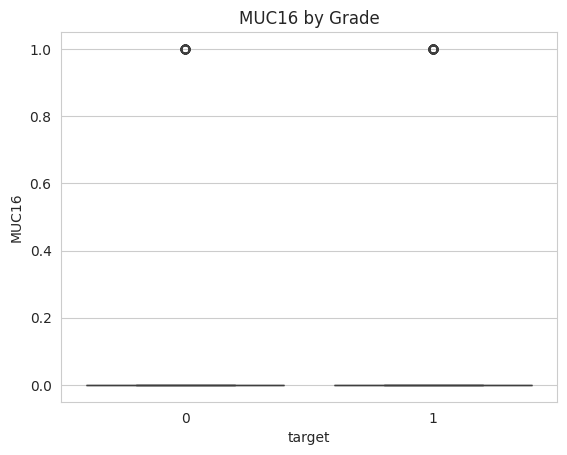

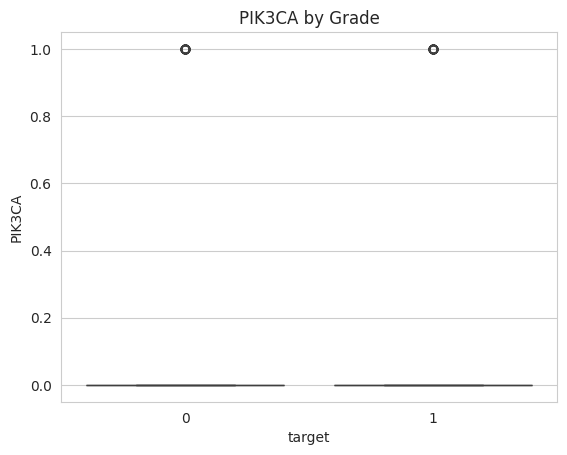

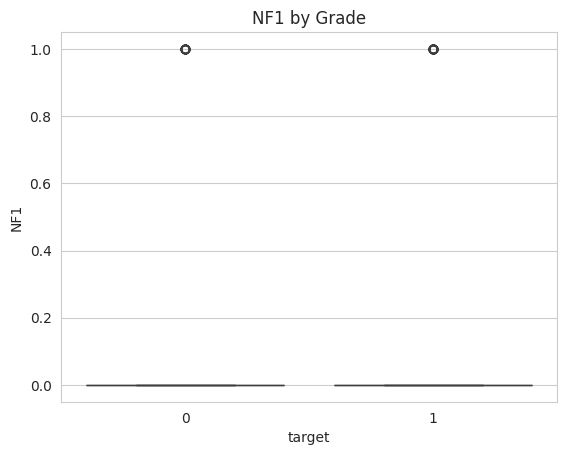

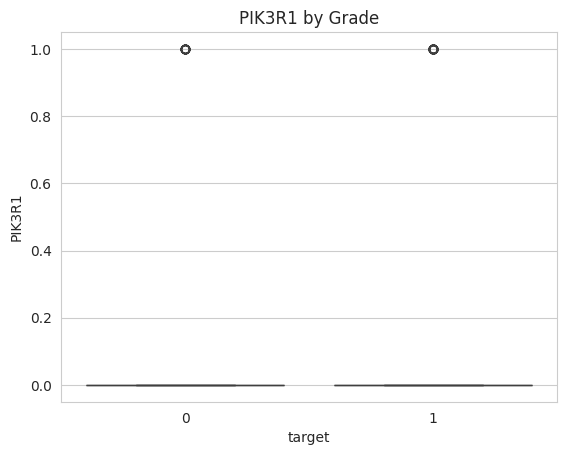

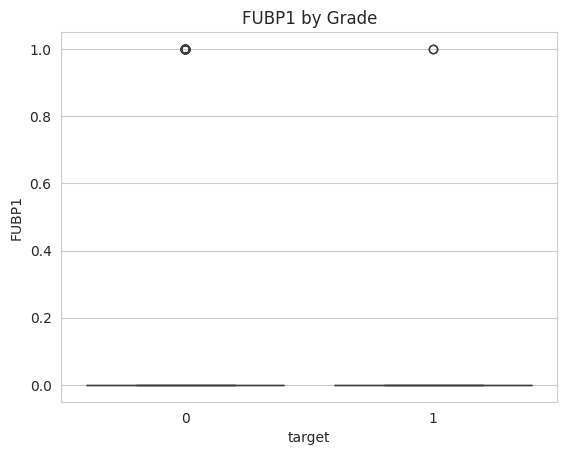

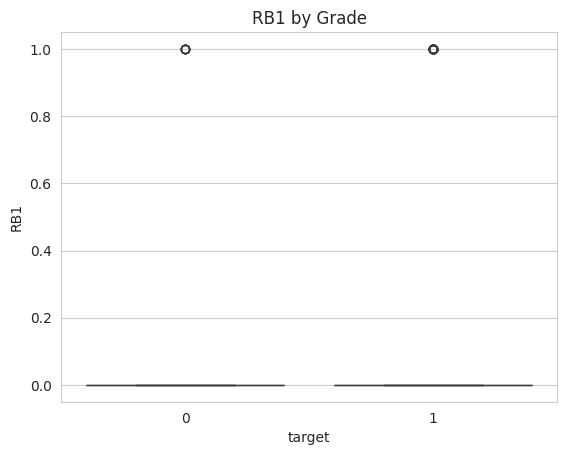

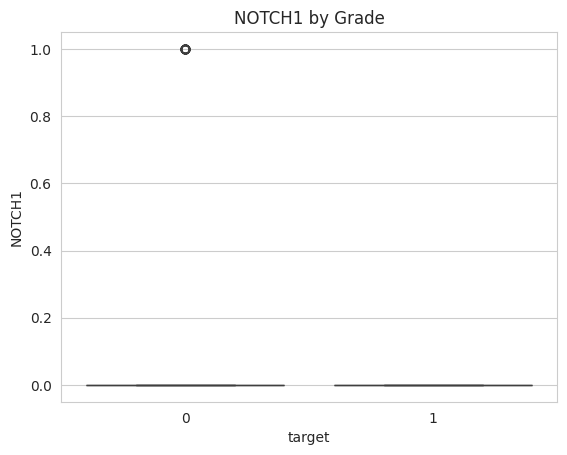

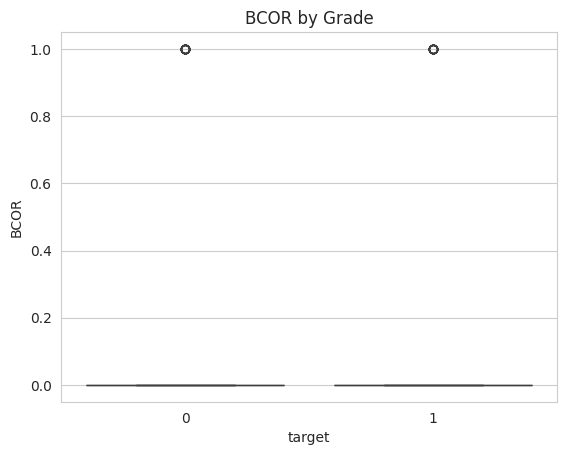

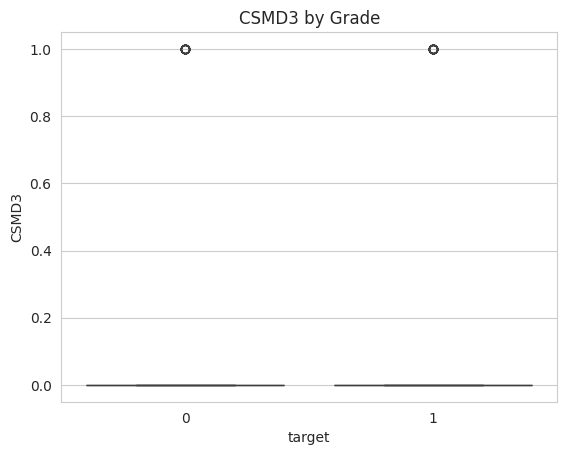

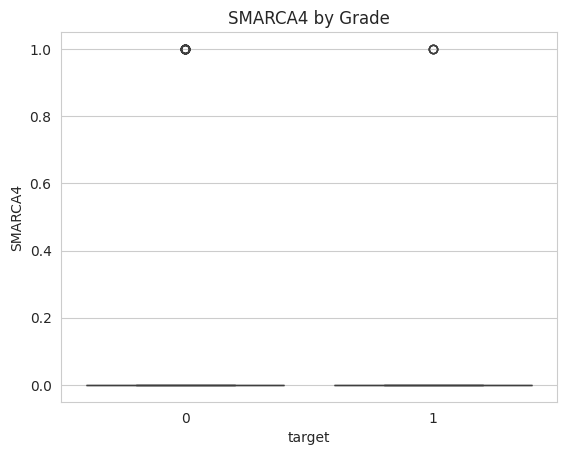

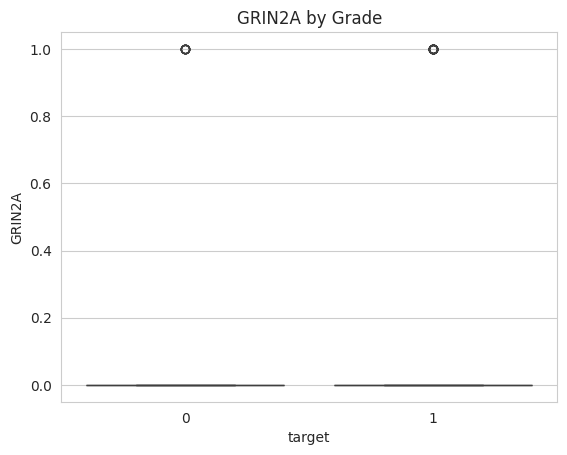

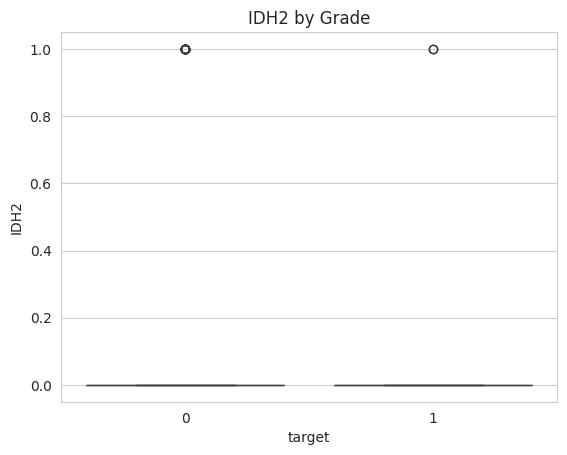

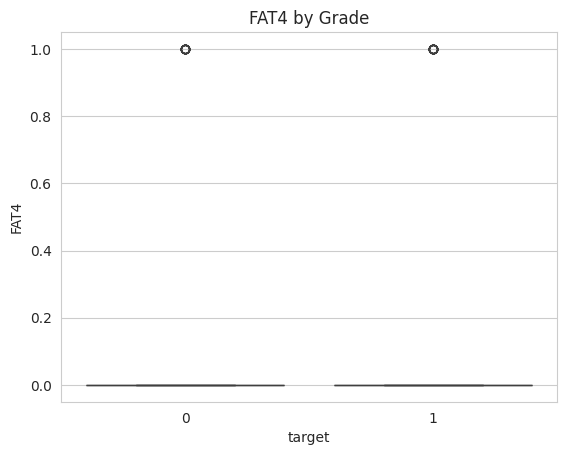

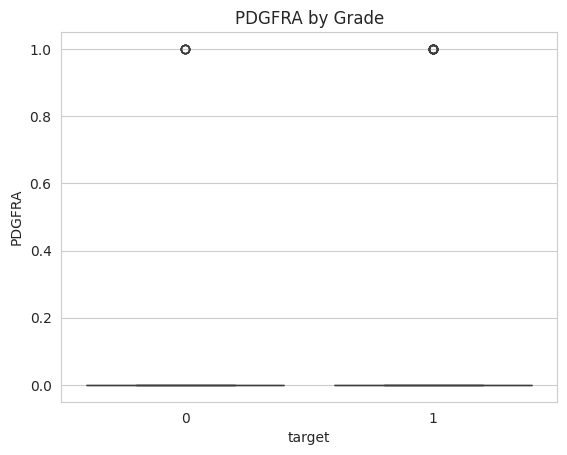

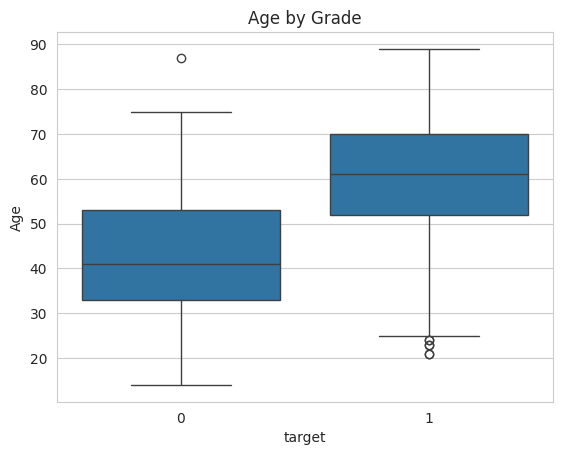

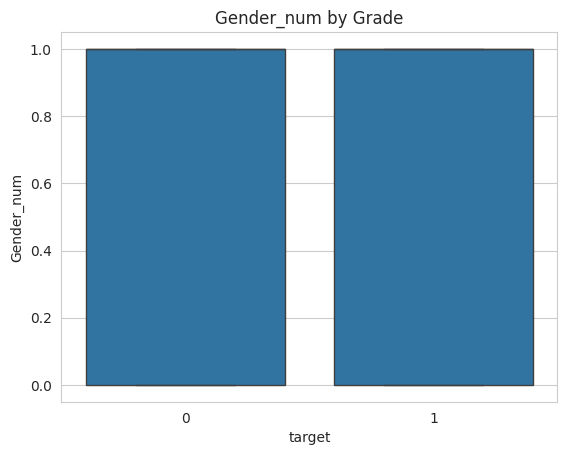

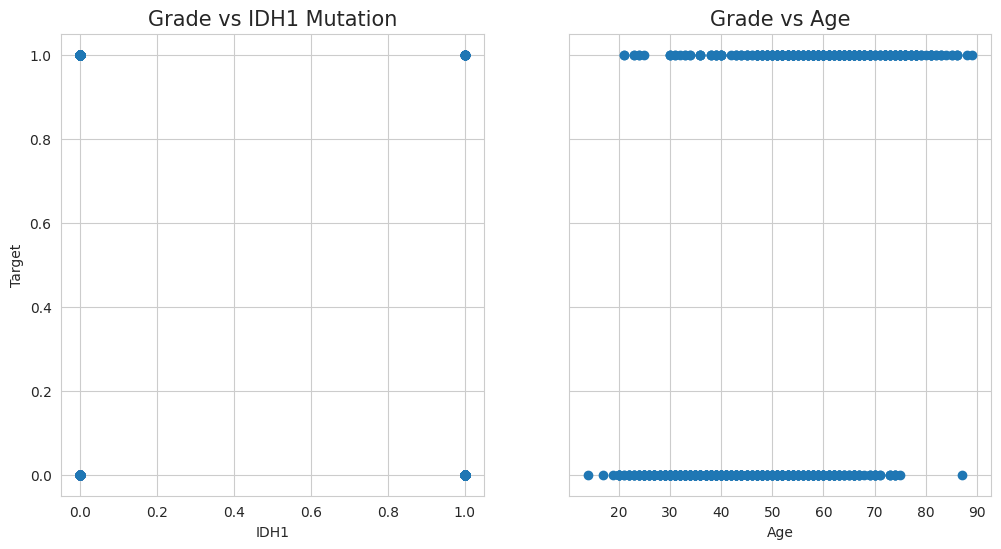

Features shape: (857, 29)
Training set size: 599
Test set size: 258


ValueError: could not convert string to float: 'GBM'

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import re

def parse_age(s):
    m = re.search(r'(\d+)\s*years?', str(s))
    return int(m.group(1)) if m else None

mut_cols = ['IDH1','TP53','ATRX','PTEN','EGFR','CIC','MUC16','PIK3CA',
            'NF1','PIK3R1','FUBP1','RB1','NOTCH1','BCOR','CSMD3',
            'SMARCA4','GRIN2A','IDH2','FAT4','PDGFRA']

# Load Data
df = pd.read_csv("TCGA_GBM_LGG_Mutations_all.csv")
df['Age'] = df['Age_at_diagnosis'].apply(parse_age)
for c in mut_cols:
    df[c] = (df[c] == 'MUTATED').astype(int)
df['Gender_num'] = (df['Gender'] == 'Male').astype(int)
df['target'] = (df['Grade'] == 'GBM').astype(int)
print(f"Dataset shape: {df.shape}")
df.head()

# Data Preprocessing
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

df = df.dropna()
print(f"Dataset shape after dropping missing values: {df.shape}")

print("Target distribution:")
print(df['target'].value_counts())

df.info()

# Exploratory Data Analysis
sns.set_style('whitegrid')
sns.countplot(x='target', data=df)
plt.title('Grade Distribution (0=LGG, 1=GBM)')
plt.xlabel('Target (0=LGG, 1=GBM)')
plt.ylabel('Count')
plt.show()

# Box plots of all features by target
feature_cols = [col for col in df.columns if col != 'target']
for feature in feature_cols:
    sns.boxplot(x='target', y=feature, data=df)
    plt.title(f'{feature} by Grade')
    plt.show()

# Scatter plots
f, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(12, 6))
ax1.scatter(df['IDH1'], df['target'])
ax1.set_title('Grade vs IDH1 Mutation', fontsize=15)
ax1.set_xlabel('IDH1')
ax1.set_ylabel('Target')
ax2.scatter(df['Age'], df['target'])
ax2.set_title('Grade vs Age', fontsize=15)
ax2.set_xlabel('Age')
plt.show()

# Training and Prediction
df_feat = df.drop('target', axis=1)
df_target = df['target']
print("Features shape:", df_feat.shape)
df_feat.head()

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    df_feat, df_target, test_size=0.30, random_state=101)
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

# Train the Support Vector Classifier
from sklearn.svm import SVC
model = SVC()
model.fit(X_train, y_train)

# Predictions and Evaluations
predictions = model.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, predictions))

print("Classification Report:")
print(classification_report(y_test, predictions))

print('Misclassification error rate:',
      round(np.mean(predictions != y_test), 3))

# GridSearch
param_grid = {'C': [0.1, 1, 10, 100, 1000],
              'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
              'kernel': ['rbf']}

from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=1)
grid.fit(X_train, y_train)

grid.best_params_
grid.best_estimator_

grid_predictions = grid.predict(X_test)
print("Confusion Matrix (after GridSearch):")
print(confusion_matrix(y_test, grid_predictions))

print("Classification Report (after GridSearch):")
print(classification_report(y_test, grid_predictions))

print('Misclassification error rate (after GridSearch):',
      round(np.mean(grid_predictions != y_test), 3))

# Another set of parameters for GridSearch
param_grid = {'C': [50, 75, 100, 125, 150],
              'gamma': [1e-2, 1e-3, 1e-4, 1e-5, 1e-6],
              'kernel': ['rbf']}

grid = GridSearchCV(SVC(tol=1e-5), param_grid, refit=True, verbose=1)
grid.fit(X_train, y_train)

grid.best_estimator_

grid_predictions = grid.predict(X_test)
print("Confusion Matrix (refined GridSearch):")
print(confusion_matrix(y_test, grid_predictions))

print("\nClassification Report (refined GridSearch):")
print(classification_report(y_test, grid_predictions))